In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Feature description:

- Age: age
- Gender: gender
- Country: country
- state: If you live in the United States, which state or territory do you live in?
- self_employed: Are you self-employed?
- family_history: Do you have a family history of mental illness?
- treatment: Have you sought treatment for a mental health condition?
- work_interfere: If you have a mental health condition, do you feel that it interferes with your work?
- no_employees: How many employees does your company or organization have?
- remote_work: Do you work remotely (outside of an office) at least 50% of the time?
- tech_company: Is your employer primarily a tech company/organization?
- benefits: Does your employer provide mental health benefits?
- care_options: Do you know the options for mental health care your employer provides?
- wellness_program: Has your employer ever discussed mental health as part of an employee wellness program?
- seek_help: Does your employer provide resources to learn more about mental health issues and how to seek help?
- anonymity: Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources?
- leave: How easy is it for you to take medical leave for a mental health condition?
- mental_health_consequence: Do you think that discussing a mental health issue with your employer would have negative consequences?
- phys_health_consequence: Do you think that discussing a physical health issue with your employer would have negative consequences?
- coworkers: Would you be willing to discuss a mental health issue with your coworkers?
- supervisor: Would you be willing to discuss a mental health issue with your direct supervisor(s)?
- mental_health_interview: Would you bring up a mental health issue with a potential employer in an interview?
- phys_health_interview: Would you bring up a physical health issue with a potential employer in an interview?
- mental_vs_physical: Do you feel that your employer takes mental health as seriously as physical health?
- obs_consequence: Have you heard of or observed negative consequences for coworkers with mental health conditions in your workplace?

In [84]:
data = pd.read_csv("../data/cleaned.csv")


In [85]:
binary_cols = [
    'treatment', 'family_history', 'remote_work', 'tech_company',
    'obs_consequence', 'benefits', 'care_options', 'wellness_program',
    'seek_help', 'anonymity', 'self_employed'
]

ordinal_cols = [
    'no_employees', 'leave',
    'mental_health_consequence', 'phys_health_consequence',
    'mental_health_interview', 'phys_health_interview',
    'mental_vs_physical', 'coworkers', 'supervisor'
]

numerical_cols = ['Age']

nominal_cols = ['Gender_clean', 'Country']

binary_nominal_cols = binary_cols + nominal_cols
all_features = binary_cols + ordinal_cols + numerical_cols + nominal_cols

target_col = 'work_interfere'

# Binary feature analysis

- cardinality pie plot
- Phi coefficient correlation matrix
-

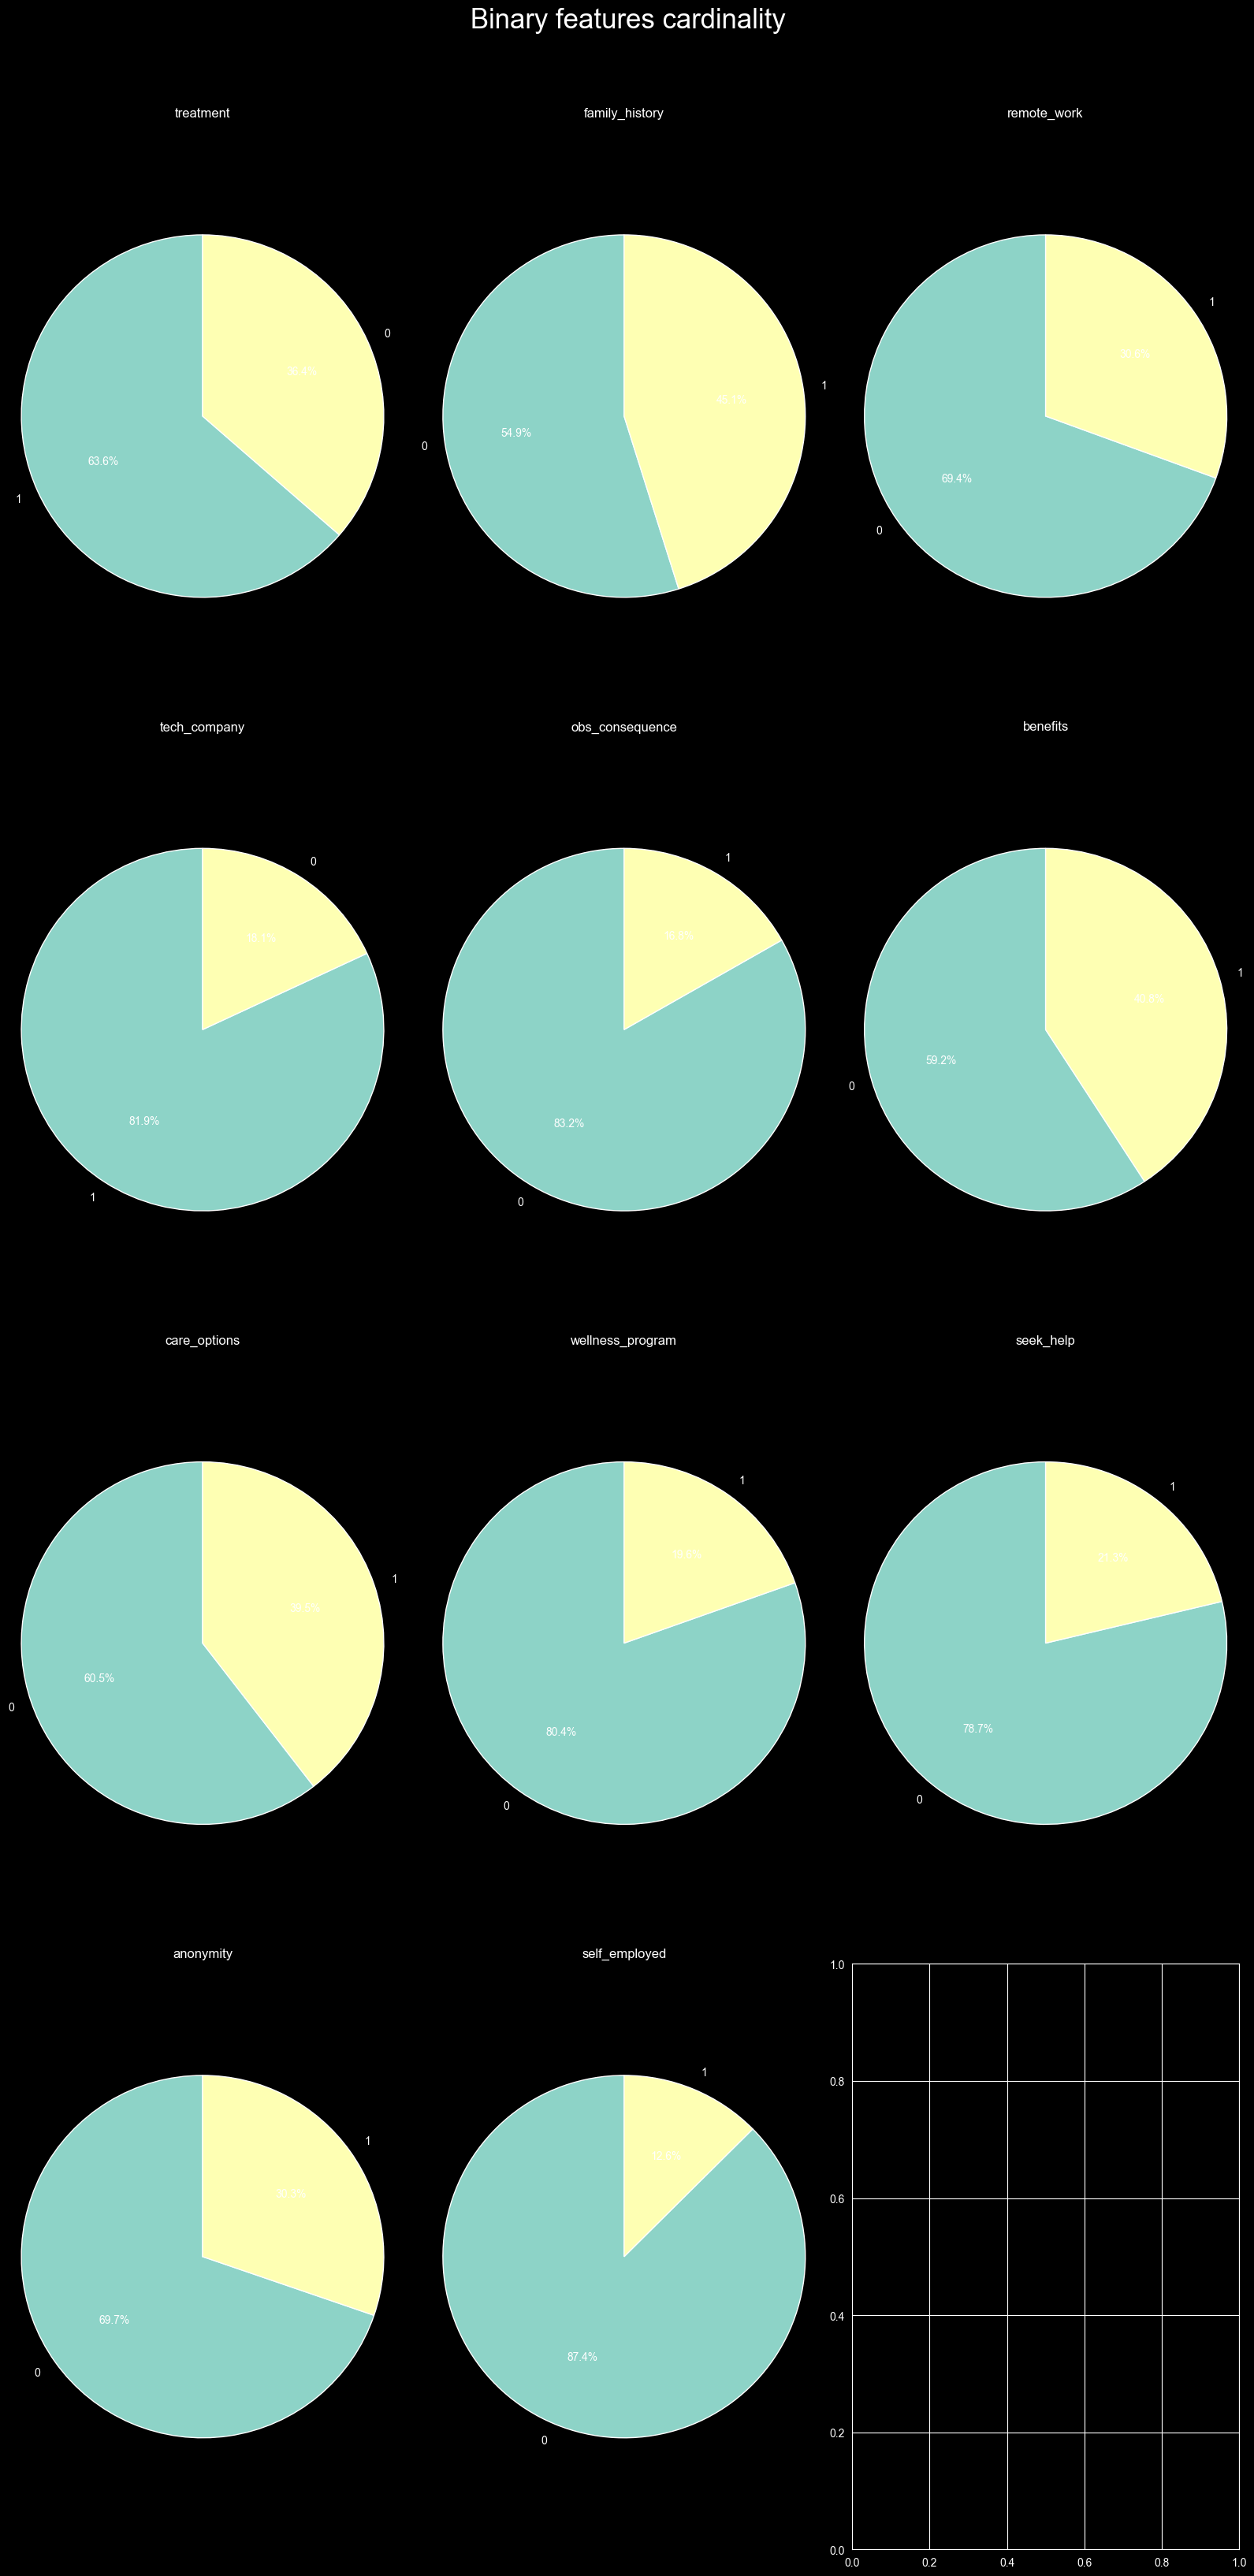

In [86]:
nrows, ncols = 4, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 32))
axes = axes.flat

for ax, col in zip(axes, binary_cols):
    sizes = data[col].value_counts()
    labels = sizes.index.astype(str)

    ax.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
    ax.set_title(col)
    ax.axis("equal")

fig.suptitle("Binary features cardinality", fontsize=25, y=1.02)
plt.tight_layout()
plt.show()

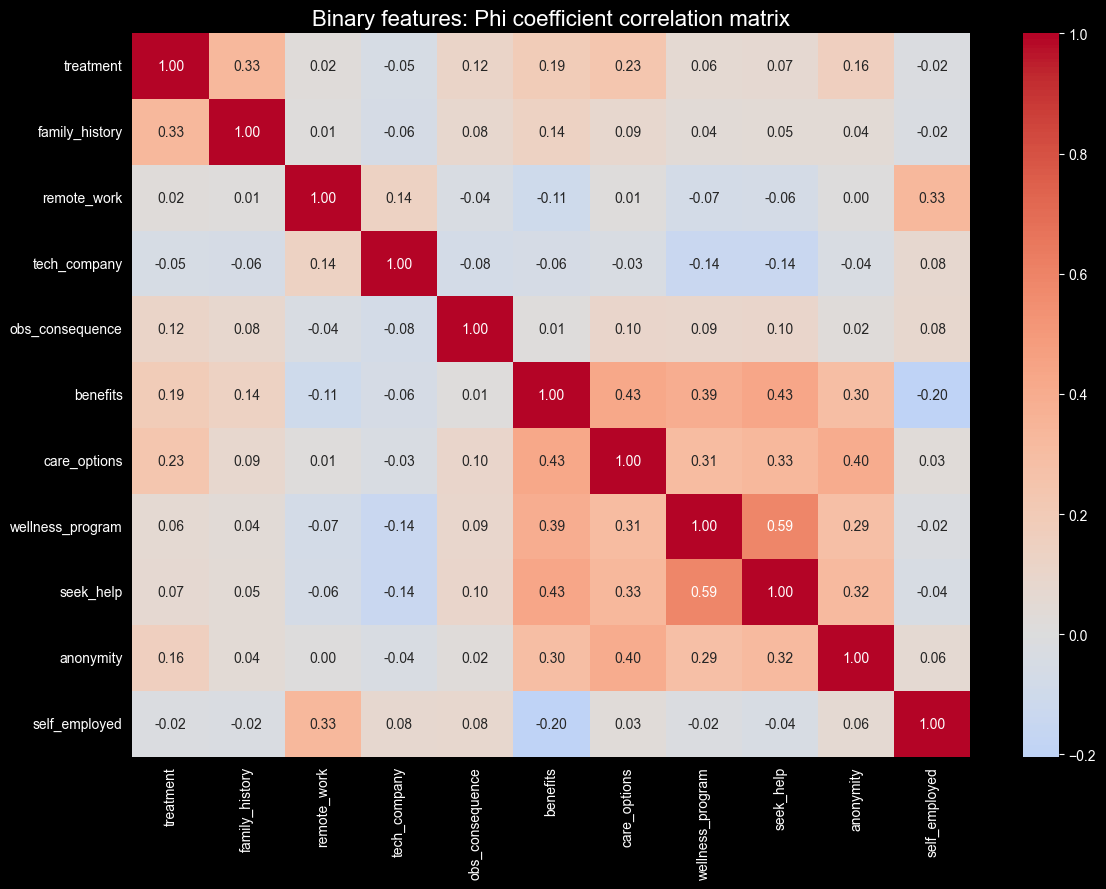

In [87]:
phi_matrix = data[binary_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(phi_matrix, annot=True, fmt=".2f", cmap="coolwarm", center = 0, ax=ax)

ax.set_title("Binary features: Phi coefficient correlation matrix", fontsize=16)
plt.tight_layout()
plt.show()